In [4]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import cupy as cp
import tqdm


best_parameters = {
    'spectral': ('CAR',          1 ,    'skew'),
    'cwt':      ('BipolarDB',60,'std'),
    'dwt':      ('Cz',10,'skew'),
    'mst':      ('BipolarDB',10,'skew'),
    'sst':      ('Laplacian',20,'skew'),
    'cc':       ('Cz',10,'skew'),
    'plv':      ('Laplacian',2,'std'),
    'gcc':      ('CAR',1,'std'),
    'gplv':     ('BipolarDB',1,'mean'),
    'utm':      ('Laplacian',60,'mean')
}

In [5]:
def load_data():
    """Load and prepare the dataset."""
    description = pd.read_csv(f'{DATA_FOLDER}/description.csv')
    labels = description['epilepsy'].to_numpy()
    subjects = description['subject'].to_numpy()
    unique_subjects = np.unique(description['subject'])
    
    subject_labels = []
    for subj in unique_subjects:
        lbl = labels[subjects == subj][0]
        subject_labels.append([subj, lbl])
    subject_labels = np.array(subject_labels)
    
    return description, labels, subjects, unique_subjects, subject_labels

def load_feature_data(feature_name):
    """Load and preprocess feature data using the best parameters for the given feature."""
    montage, segment_length, combiner = best_parameters[feature_name]
    data = np.load(f'{DATA_FOLDER}/{feature_name}_{montage}_{segment_length}s_{combiner}.npy')
    data = handle_complex_numbers(data)
    
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)
    return data, montage, segment_length, combiner

def handle_complex_numbers(features):
    """Handle complex numbers and infinite values in features."""
    if isinstance(features, pd.DataFrame):
        for column in features.columns:
            if np.iscomplexobj(features[column]):
                features[column] = features[column].apply(np.abs)
            features[column].replace([np.inf, -np.inf], np.nan, inplace=True)
    elif isinstance(features, np.ndarray):
        if np.iscomplexobj(features):
            features = np.abs(features)
        features[~np.isfinite(features)] = np.nan
    return features

In [6]:
DATA_FOLDER = '/space/gzanardini/tuh_whole/split'

#load data
description, labels, subjects, unique_subjects, subject_labels = load_data()


In [7]:
from typing import List, Dict, Iterable, Tuple, Optional


UTM_METRICS: List[str] = [
    'Mean', 'Median', 'SD', 'Skew', 'Kurtosis',
    'ZC', 'NLEO_Env_Diff', 'NLEO_Teager',
    'Energy_T', 'Energy_F',
    'Entropy', 'Vpp', 'NPks'
]


chs = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
       'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

def utm_index_to_name(idx: int,  channels: Iterable[str]):
    N = len(channels)
    M = len(UTM_METRICS)
    total = N * M

    ch_id, met_id = divmod(idx, M)
    ch_label = channels[ch_id]
    metric = UTM_METRICS[met_id]

    # optional verbosity patch: map 'skew'->'skewness' when combiner printed?
    metric_full_map = {'skew': 'skewness', 'kurtosis': 'kurtosis'}
    metric_full = metric_full_map.get(metric, metric)

    parts = ['UTM']
    parts.append(metric_full)
    parts.append(ch_label)
    return '_'.join(parts)

feature_names=[utm_index_to_name(i, channels=chs) for i in range(247)]

(40, 247)
######


Processing utm: 100%|██████████| 31/31 [00:07<00:00,  3.93it/s]


Feature: utm - montage: Laplacian, segment_length: 60, combiner: mean


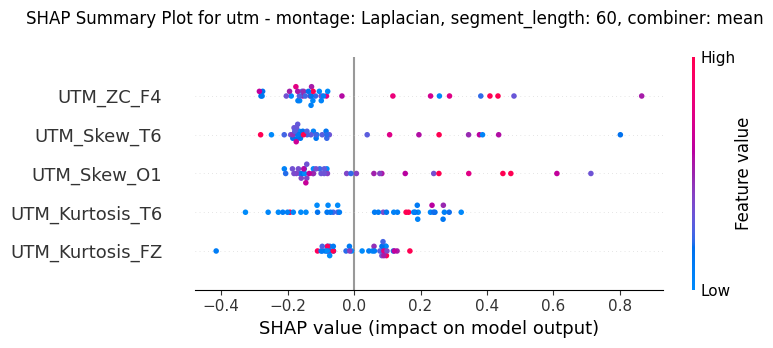

In [8]:
# for each of the best parameters, load the data and compute shapley values

for i, feature_name in enumerate(['utm']):
    data, montage, segment_length, combiner = load_feature_data(feature_name)
    data = handle_complex_numbers(data)
    print(data.shape)
    print('######')

    shap_values_folds = []

    for subj in tqdm.tqdm(unique_subjects, desc=f'Processing {feature_name}'):
        test_indices = np.where(subjects == subj)[0]
        train_indices = np.where(subjects != subj)[0]

        X_train, X_test = data[train_indices], data[test_indices]
        y_train, y_test = labels[train_indices], labels[test_indices]

        ratio = (len(y_train) - sum(y_train)) / sum(y_train)

        model = XGBClassifier(
            scale_pos_weight=ratio,
            n_jobs=4,
            device='cpu',
            n_estimators=100,
            max_depth=6,
            subsample=0.9,
            gamma=0.1,
            learning_rate=0.01
        )

        model.fit(X_train, y_train)

        # Compute SHAP values
        explainer = shap.Explainer(model, X_train)
        shap_values = explainer.shap_values(X_test)

        for shap_value in shap_values:
            shap_values_folds.append(shap_value)

    print(f'Feature: {feature_name} - montage: {montage}, segment_length: {segment_length}, combiner: {combiner}')

    fig = plt.figure(figsize=(8, 5))
    plt.suptitle(f'SHAP Summary Plot for {feature_name} - montage: {montage}, segment_length: {segment_length}, combiner: {combiner}')
    ax0=fig.add_subplot(111)
    shap.summary_plot(
        np.array(shap_values_folds),
        data, max_display=5, show=False, feature_names=feature_names)   
    plt.tight_layout()
#
    if feature_name == 'utm':
        plt.savefig(f'shap_summary_{feature_name}_tuh_withieds.pdf')
    plt.show()
    #shap.summar
    